# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset yang digunakan adalah **Smart Shipment Logistics** hasil *sampling* mandiri. Dataset ini memuat logistik pengiriman, informasi rute, jenis kendaraan, dan status pengiriman akhir.
Tujuan eksperimen ini adalah membangun model klasifikasi untuk memprediksi apakah suatu paket akan mengalami keterlambatan (`Delayed`) atau tepat waktu (`On-Time`) berdasarkan fitur logistik yang ada.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
try:
    df = pd.read_csv('smart_shipment_logistics.csv')
    print("Dataset berhasil dimuat!")
    display(df.head())
    print(f"Dimensi dataset: {df.shape}")
except FileNotFoundError:
    print("File tidak ditemukan. Pastikan Anda sudah mengunggah smart_shipment_logistics.csv")

Dataset berhasil dimuat!


,shipment_id,carrier,origin_port,destination_port,transport_mode,status,goods_category,currency,created_date,eta_date,...,freight_cost_usd,num_containers,num_stops,delay_hours,risk_score,weather_severity,port_congestion,temperature_c,priority_level,insurance_required
0,SHP-103577889,Kuehne_Nagel,Tokyo,Savannah,sea,On_Schedule,Consumer_Goods,EUR,2024-06-25,2024-07-07,...,6451.92,23,0,0.0,0.5477,0.1965,0.2397,-18.1,2,False
1,SHP-104993933,CMA_CGM,Shanghai,Hamburg,sea,On_Schedule,Food_Beverage,SGD,2022-08-18,2022-08-23,...,1598.23,1,2,0.0,0.0507,0.2309,0.2255,NaN,2,True
2,SHP-104094901,Hapag-Lloyd,Tanjung_Pelepas,Houston,sea,On_Schedule,Raw_Materials,SGD,2023-07-23,2023-07-28,...,154.30,1,0,0.0,0.7394,0.1631,0.6634,NaN,2,True
3,SHP-104420498,Hapag-Lloyd,Singapore,Genoa,rail,On_Schedule,Automotive,SGD,2023-04-30,2023-05-08,...,1211.22,22,0,0.0,0.5743,0.2408,0.7115,NaN,1,True
4,SHP-100634466,UPS,Shanghai,New_York,sea,On_Schedule,Perishables,EUR,2022-11-15,2022-11-25,...,368.42,17,1,0.0,0.3524,0.3002,0.4974,NaN,4,False


Dimensi dataset: (5000, 25)


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Informasi Umum Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   shipment_id         5000 non-null   object 
 1   carrier             5000 non-null   object 
 2   origin_port         5000 non-null   object 
 3   destination_port    5000 non-null   object 
 4   transport_mode      5000 non-null   object 
 5   status              5000 non-null   object 
 6   goods_category      5000 non-null   object 
 7   currency            5000 non-null   object 
 8   created_date        5000 non-null   object 
 9   eta_date            5000 non-null   object 
 10  transit_hours       5000 non-null   float64
 11  distance_km         5000 non-null   float64
 12  weight_kg           5000 non-null   float64
 13  volume_m3           5000 non-null   float64
 14  value_usd           5000 non-null   float64
 15  freight_cost_usd    5000 non-nu

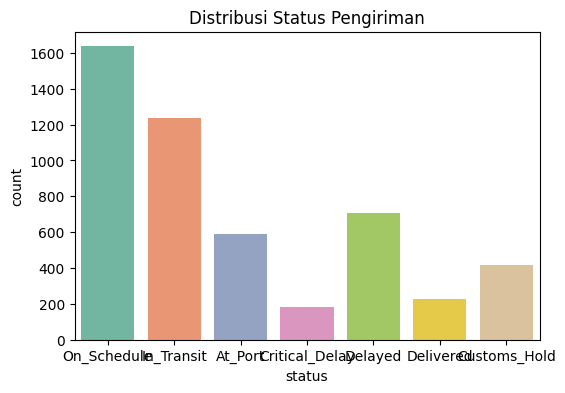


Jumlah Missing Values per Kolom:
shipment_id              0
carrier                  0
origin_port              0
destination_port         0
transport_mode           0
status                   0
goods_category           0
currency                 0
created_date             0
eta_date                 0
transit_hours            0
distance_km              0
weight_kg                0
volume_m3                0
value_usd                0
freight_cost_usd         0
num_containers           0
num_stops                0
delay_hours              0
risk_score               0
weather_severity         0
port_congestion          0
temperature_c         3530
priority_level           0
insurance_required       0
dtype: int64


In [4]:
print("Informasi Umum Dataset:")
df.info()

print("\nDistribusi Target (status):")
print(df['status'].value_counts())

# Visualisasi Target
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='status', palette='Set2')
plt.title('Distribusi Status Pengiriman')
plt.show()

# Cek Missing Values
print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
import os
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Menghapus kolom identifier dan datetime yang tidak relevan untuk ML
cols_to_drop = ['shipment_id', 'created_date', 'eta_date']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

# 2. Menangani Missing Values (Menggunakan median untuk kolom numerik seperti temperature_c)
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

# 3. Menghapus Duplikat
df.drop_duplicates(inplace=True)

# 4. Encoding Data Kategorikal dan Boolean (termasuk kolom 'status')
label_encoders = {}
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns

for col in categorical_cols:
    le = LabelEncoder()
    # Mengubah tipe boolean menjadi string sementara untuk di-encode menjadi 0 dan 1
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# 5. Normalisasi/Standarisasi Fitur Numerik (Kecuali target 'status')
scaler = StandardScaler()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

if 'status' in numerical_cols:
    numerical_cols = numerical_cols.drop('status')

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# 6. Menyimpan data yang sudah diproses
os.makedirs('dataset_preprocessing', exist_ok=True)
df.to_csv('dataset_preprocessing/dataset_ready.csv', index=False)
joblib.dump(scaler, 'dataset_preprocessing/scaler.pkl')

print("Preprocessing selesai! Data disimpan di folder 'dataset_preprocessing'.")
display(df.head())

Preprocessing selesai! Data disimpan di folder 'dataset_preprocessing'.


,carrier,origin_port,destination_port,transport_mode,status,goods_category,currency,transit_hours,distance_km,weight_kg,...,freight_cost_usd,num_containers,num_stops,delay_hours,risk_score,weather_severity,port_congestion,temperature_c,priority_level,insurance_required
0,0.221531,1.635753,1.139047,0.774037,6,-0.852418,-0.315434,0.123697,0.487817,-0.294540,...,-0.118010,1.508418,-1.445137,-0.364644,1.651016,-0.022540,-0.524091,-2.883186,-0.433686,-1.233463
1,-1.630732,0.944409,-0.431282,0.774037,6,-0.158040,0.846385,-0.651445,0.710483,4.044345,...,-0.171344,-1.626520,-0.279422,-0.364644,-1.468025,0.225516,-0.604585,0.001002,-0.433686,0.810725
2,-0.010002,1.462917,-0.256801,0.774037,6,1.230715,0.846385,-0.639714,2.085067,-0.316239,...,-0.187210,-1.626520,-1.445137,-0.364644,2.854074,-0.263385,1.877698,0.001002,-0.433686,0.810725
3,-0.010002,1.117245,-0.605763,-0.884850,6,-1.546796,0.846385,-0.386339,-1.182632,-0.339423,...,-0.175596,1.365921,-1.445137,-0.364644,1.817950,0.296904,2.150358,0.001002,-1.326044,0.810725
4,1.147662,0.944409,0.615604,0.774037,6,0.536337,-0.315434,-0.125925,-0.617897,1.823304,...,-0.184857,0.653435,-0.862279,-0.364644,0.425364,0.725233,0.936709,0.001002,1.351030,-1.233463
